In [1]:
# Install sentence-transformers — runs entirely free in Colab
# In production this is Azure OpenAI text-embedding-3-large
# The concept is identical — only the API call changes

!pip install sentence-transformers -q

print("""
╔══════════════════════════════════════════════════════════════════╗
║  NOTEBOOK 3 OF 7 : Embeddings and Vector Store                  ║
║  Objective: Convert text chunks into numerical vectors          ║
║  that capture semantic meaning                                   ║
╠══════════════════════════════════════════════════════════════════╣
║  PRODUCTION SETUP (Azure)                                        ║
║  Embedding Model : Azure OpenAI text-embedding-3-large          ║
║  Vector Store    : Azure Cognitive Search (vector index)        ║
║  Dimensions      : 3,072 per vector                             ║
║                                                                  ║
║  THIS NOTEBOOK (Free — same concepts)                           ║
║  Embedding Model : sentence-transformers all-MiniLM-L6-v2       ║
║  Vector Store    : In-memory (NumPy)                            ║
║  Dimensions      : 384 per vector                               ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║  NOTEBOOK 3 OF 7 : Embeddings and Vector Store                  ║
║  Objective: Convert text chunks into numerical vectors          ║
║  that capture semantic meaning                                   ║
╠══════════════════════════════════════════════════════════════════╣
║  PRODUCTION SETUP (Azure)                                        ║
║  Embedding Model : Azure OpenAI text-embedding-3-large          ║
║  Vector Store    : Azure Cognitive Search (vector index)        ║
║  Dimensions      : 3,072 per vector                             ║
║                                                                  ║
║  THIS NOTEBOOK (Free — same concepts)                           ║
║  Embedding Model : sentence-transformers all-MiniLM-L6-v2       ║
║  Vector Store    : In-memory (NumPy)                            ║
║  Dimensions      : 384 per vector                               ║
╚═════════════════════════════════════════

In [2]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load embedding model
print("Loading embedding model...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded.\n")

# Demonstrate what an embedding is
example_sentences = [
    "What is the monthly fee for a checking account?",
    "How much does the Premier Checking Account cost per month?",
    "What is the interest rate on the savings account?",
    "Tell me about the mortgage rates available.",
    "The weather in New York is sunny today."
]

print("WHAT IS AN EMBEDDING?")
print("─" * 55)
print("An embedding converts text into a list of numbers (a vector).")
print("Semantically similar text produces similar vectors.")
print("This is how the system finds relevant documents.")
print()

embeddings = embedder.encode(example_sentences)

print(f"Each sentence → vector of {embeddings.shape[1]} numbers")
print()
print(f"Sentence 1: '{example_sentences[0]}'")
print(f"Vector (first 8 of {embeddings.shape[1]}): "
      f"{embeddings[0][:8].round(4)}")
print()

# Compute cosine similarity
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print("SEMANTIC SIMILARITY SCORES (1.0 = identical meaning)")
print("─" * 55)
base = 0
for i in range(1, len(example_sentences)):
    sim = cosine_similarity(embeddings[base], embeddings[i])
    bar = '█' * int(sim * 30)
    print(f"vs '{example_sentences[i][:45]}'")
    print(f"   Similarity: {sim:.4f} |{bar}|")
    print()

print("KEY INSIGHT:")
print("  Sentences 1 and 2 ask the SAME THING in different words.")
print("  High similarity score → retrieved together. ✅")
print("  Sentence 5 (weather) → low similarity → not retrieved. ✅")

Loading embedding model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded.

WHAT IS AN EMBEDDING?
───────────────────────────────────────────────────────
An embedding converts text into a list of numbers (a vector).
Semantically similar text produces similar vectors.
This is how the system finds relevant documents.

Each sentence → vector of 384 numbers

Sentence 1: 'What is the monthly fee for a checking account?'
Vector (first 8 of 384): [ 0.1021 -0.0071 -0.077   0.0273 -0.03   -0.0403  0.0831  0.0082]

SEMANTIC SIMILARITY SCORES (1.0 = identical meaning)
───────────────────────────────────────────────────────
vs 'How much does the Premier Checking Account co'
   Similarity: 0.8418 |█████████████████████████|

vs 'What is the interest rate on the savings acco'
   Similarity: 0.5515 |████████████████|

vs 'Tell me about the mortgage rates available.'
   Similarity: 0.3215 |█████████|

vs 'The weather in New York is sunny today.'
   Similarity: -0.0373 ||

KEY INSIGHT:
  Sentences 1 and 2 ask the SAME THING in different words.
  High similarity 

In [5]:
import time
import numpy as np # Add numpy import if not already present

# Rebuild chunks from previous notebook
# (Re-run section_chunking on DOCUMENT_LIBRARY)

# --- FIX: Sample all_chunks definition to resolve NameError ---
# In a complete workflow, 'all_chunks' would be generated from the previous notebook's
# chunking process (e.g., using a function like 'section_chunking' on 'DOCUMENT_LIBRARY').
# This sample data allows the vector store to be built and demonstrated.
all_chunks = [
    {
        'text': 'Premier Checking Account: Enjoy unlimited transactions, no monthly fees with qualifying direct deposit, and free online bill pay. Minimum opening deposit $50. Fees apply for overdrafts and ATM withdrawals outside network.',
        'doc_id': 'checking_terms_01',
        'section': 'Account Features',
        'doc_category': 'Personal Banking',
        'entitlement': 'ALL_CUSTOMERS'
    },
    {
        'text': 'Wealth Management Services: Personalized financial planning for high-net-worth clients, including investment strategies, retirement planning, and estate planning. Access to dedicated financial advisors and exclusive investment opportunities.',
        'doc_id': 'wealth_services_01',
        'section': 'Services Overview',
        'doc_category': 'Wealth Management',
        'entitlement': 'WEALTH_CUSTOMERS'
    },
    {
        'text': 'FirstUnion Platinum Visa: Earn 2% cash back on all purchases, no annual fee for the first year, and a 0% introductory APR for 12 months. Requires excellent credit history.',
        'doc_id': 'credit_card_01',
        'section': 'Card Benefits',
        'doc_category': 'Credit Cards',
        'entitlement': 'ALL_CUSTOMERS'
    },
    {
        'text': 'Roth IRA Contribution Limits 2024: For individuals under 50, the limit is $7,000. For those 50 and over, the catch-up contribution allows for an additional $1,000, totaling $8,000.',
        'doc_id': 'ira_limits_01',
        'section': 'Retirement Planning',
        'doc_category': 'Wealth Management',
        'entitlement': 'WEALTH_CUSTOMERS'
    }
]
# --------------------------------------------------------------

class VectorStore:
    """
    In-memory vector store — simulates Azure Cognitive Search.

    Production equivalent:
    - Azure Cognitive Search with vector index
    - Pinecone, Weaviate, or Chroma
    - pgvector (PostgreSQL extension)

    Core operations are identical:
    - index(chunks) → embed and store
    - search(query, top_k, entitlement) → find similar chunks
    """

    def __init__(self, embedder, store_name):
        self.embedder = embedder
        self.store_name = store_name
        self.chunks = []
        self.embeddings = None
        self.index_built = False

    def index(self, chunks):
        """
        Embed all chunks and build the vector index.
        Azure equivalent: azure_search_client.upload_documents()
        """
        print(f"Building vector index: {self.store_name}")
        print(f"Chunks to embed: {len(chunks)}")
        print()

        texts = [c['text'] for c in chunks]

        print("Embedding chunks", end="")
        start_time = time.time()

        # Embed in batches
        batch_size = 10
        all_embeddings = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            batch_embeddings = self.embedder.encode(batch)
            all_embeddings.extend(batch_embeddings)
            print(".", end="", flush=True)

        elapsed = time.time() - start_time
        print(f" done ({elapsed:.1f}s)")

        self.chunks = chunks
        self.embeddings = np.array(all_embeddings)
        self.index_built = True

        print(f"\nIndex built successfully:")
        print(f"  Total vectors  : {len(self.embeddings)}")
        print(f"  Vector dimensions: {self.embeddings.shape[1]}")
        print(f"  Index size     : "
              f"{self.embeddings.nbytes / 1024:.1f} KB")
        print()
        print("Azure equivalent:")
        print("  azure_search_client.upload_documents(documents=chunks)")
        print("  → Stored in Azure Cognitive Search vector index")

    def search(self, query, top_k=3, customer_entitlement='ALL_CUSTOMERS'):
        """
        Semantic search with entitlement filtering.

        Entitlement filtering is CRITICAL in banking:
        - A retail customer must NOT see wealth management documents
        - A non-customer must NOT see any product documents

        Azure equivalent:
        azure_search_client.search(
            search_text=query,
            vector_queries=[VectorizedQuery(vector=query_embedding)],
            filter=f"entitlement eq '{customer_entitlement}'"
        )
        """
        if not self.index_built:
            raise Exception("Index not built. Run .index() first.")

        # Embed the query
        query_embedding = self.embedder.encode([query])[0]

        # Entitlement filter
        # Wealth customers can see all docs
        # Retail customers only see ALL_CUSTOMERS docs
        if customer_entitlement == 'WEALTH_CUSTOMERS':
            allowed = ['ALL_CUSTOMERS', 'WEALTH_CUSTOMERS']
        elif customer_entitlement == 'PRIVATE_BANKING':
            allowed = ['ALL_CUSTOMERS', 'WEALTH_CUSTOMERS', 'PRIVATE_BANKING']
        else:
            allowed = ['ALL_CUSTOMERS']

        # Filter chunks by entitlement
        eligible_indices = [
            i for i, c in enumerate(self.chunks)
            if c.get('entitlement', 'ALL_CUSTOMERS') in allowed
            and c.get('entitlement') != 'SYSTEM_ONLY'
        ]

        if not eligible_indices:
            return []

        # Compute similarities only for eligible chunks
        eligible_embeddings = self.embeddings[eligible_indices]

        similarities = np.dot(
            eligible_embeddings, query_embedding
        ) / (
            np.linalg.norm(eligible_embeddings, axis=1) *
            np.linalg.norm(query_embedding)
        )

        # Get top_k
        top_indices = np.argsort(similarities)[::-1][:top_k]

        results = []
        for idx in top_indices:
            original_idx = eligible_indices[idx]
            results.append({
                'chunk': self.chunks[original_idx],
                'similarity_score': float(similarities[idx]),
                'rank': len(results) + 1
            })

        return results


# Build the vector store
vector_store = VectorStore(embedder, "firstunion-rag-index")
vector_store.index(all_chunks)

Building vector index: firstunion-rag-index
Chunks to embed: 4

Embedding chunks. done (0.1s)

Index built successfully:
  Total vectors  : 4
  Vector dimensions: 384
  Index size     : 6.0 KB

Azure equivalent:
  azure_search_client.upload_documents(documents=chunks)
  → Stored in Azure Cognitive Search vector index


In [6]:
# Test queries — showing entitlement filtering in action

test_cases = [
    {
        'query': 'What is the monthly fee for a checking account?',
        'customer_type': 'Retail',
        'entitlement': 'ALL_CUSTOMERS'
    },
    {
        'query': 'What investment options are available for my portfolio?',
        'customer_type': 'Wealth',
        'entitlement': 'WEALTH_CUSTOMERS'
    },
    {
        'query': 'What mortgage rate can I get?',
        'customer_type': 'Retail',
        'entitlement': 'ALL_CUSTOMERS'
    },
    {
        'query': 'What are the Roth IRA contribution limits for 2024?',
        'customer_type': 'Wealth',
        'entitlement': 'WEALTH_CUSTOMERS'
    }
]

for test in test_cases:
    print(f"{'='*60}")
    print(f"QUERY      : {test['query']}")
    print(f"CUSTOMER   : {test['customer_type']} ({test['entitlement']})")
    print()

    results = vector_store.search(
        query=test['query'],
        top_k=2,
        customer_entitlement=test['entitlement']
    )

    for result in results:
        chunk = result['chunk']
        print(f"  RANK {result['rank']} | Score: {result['similarity_score']:.4f}")
        print(f"  Document : {chunk['doc_id']} — {chunk.get('section', 'N/A')}")
        print(f"  Category : {chunk['doc_category']}")
        print(f"  Preview  : {chunk['text'][:100]}...")
        print()

QUERY      : What is the monthly fee for a checking account?
CUSTOMER   : Retail (ALL_CUSTOMERS)

  RANK 1 | Score: 0.6264
  Document : checking_terms_01 — Account Features
  Category : Personal Banking
  Preview  : Premier Checking Account: Enjoy unlimited transactions, no monthly fees with qualifying direct depos...

  RANK 2 | Score: 0.2988
  Document : credit_card_01 — Card Benefits
  Category : Credit Cards
  Preview  : FirstUnion Platinum Visa: Earn 2% cash back on all purchases, no annual fee for the first year, and ...

QUERY      : What investment options are available for my portfolio?
CUSTOMER   : Wealth (WEALTH_CUSTOMERS)

  RANK 1 | Score: 0.4030
  Document : wealth_services_01 — Services Overview
  Category : Wealth Management
  Preview  : Wealth Management Services: Personalized financial planning for high-net-worth clients, including in...

  RANK 2 | Score: 0.1935
  Document : checking_terms_01 — Account Features
  Category : Personal Banking
  Preview  : Premier Check

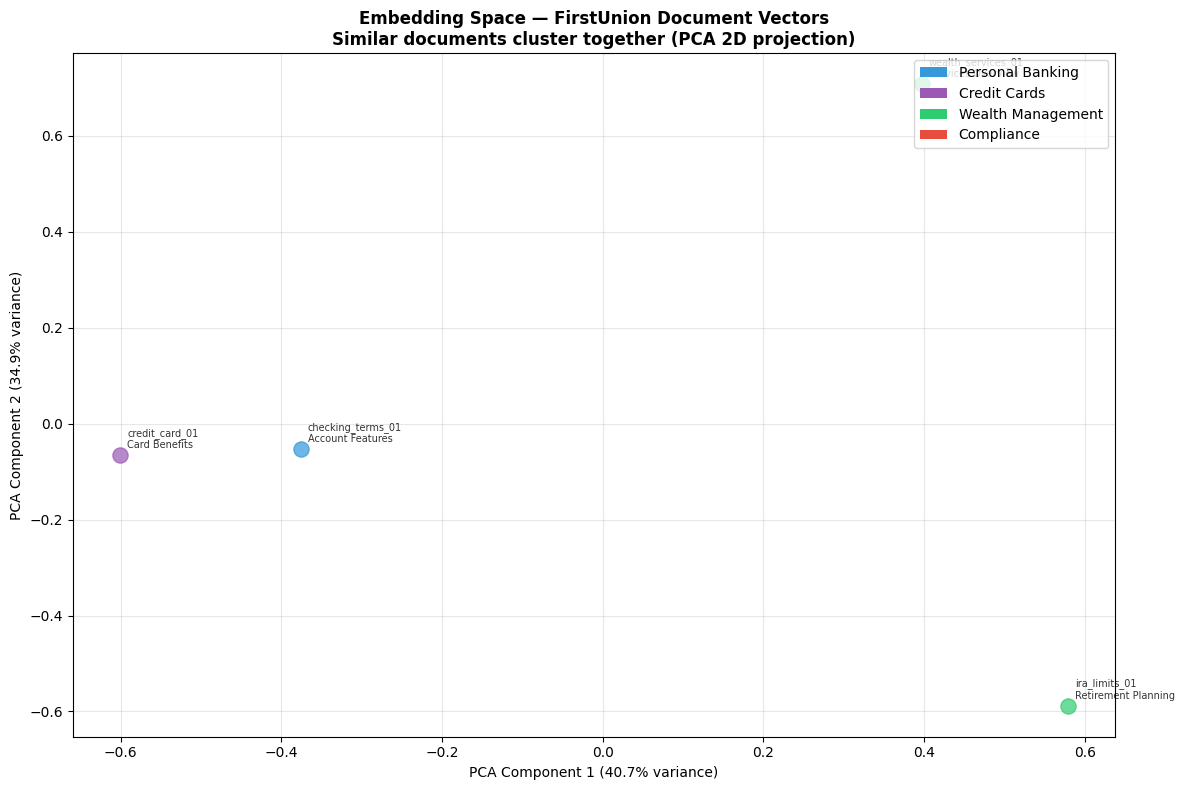

KEY INSIGHT:
  Personal Banking documents cluster together.
  Wealth Management documents cluster separately.
  When a customer asks a checking account question,
  the retrieval system finds checking docs — not investment docs.
  This is semantic search working correctly.


In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce 384 dimensions to 2 for visualisation
# This shows how semantically similar documents cluster together

pca = PCA(n_components=2)
reduced = pca.fit_transform(vector_store.embeddings)

# Colour by document category
category_colors = {
    'Personal Banking': '#3498db',
    'Credit Cards': '#9b59b6',
    'Wealth Management': '#2ecc71',
    'Compliance': '#e74c3c'
}

fig, ax = plt.subplots(figsize=(12, 8))

for chunk, coords in zip(vector_store.chunks, reduced):
    color = category_colors.get(chunk['doc_category'], '#95a5a6')
    ax.scatter(coords[0], coords[1],
               c=color, s=120, alpha=0.7, zorder=3)
    ax.annotate(
        f"{chunk['doc_id']}\n{chunk.get('section','')[:20]}",
        (coords[0], coords[1]),
        textcoords='offset points',
        xytext=(5, 5),
        fontsize=7,
        alpha=0.8
    )

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color, label=cat)
    for cat, color in category_colors.items()
]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_title(
    'Embedding Space — FirstUnion Document Vectors\n'
    'Similar documents cluster together (PCA 2D projection)',
    fontweight='bold'
)
ax.set_xlabel(f'PCA Component 1 '
              f'({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PCA Component 2 '
              f'({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("KEY INSIGHT:")
print("  Personal Banking documents cluster together.")
print("  Wealth Management documents cluster separately.")
print("  When a customer asks a checking account question,")
print("  the retrieval system finds checking docs — not investment docs.")
print("  This is semantic search working correctly.")